# 1. Import Libraries

In [39]:
!pip install transformers scikit-learn datasets 'accelerate>=1.1.0'
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from datasets import Dataset
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


# 2. Load Model

In [10]:
model_name = "w11wo/indonesian-roberta-base-sentiment-classifier"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5287.40it/s]


# 3. Prepare Dataset

In [40]:
df = pd.read_csv("../dataset/dataset.csv")

labels_map = {
    "Positive": 2,
    "Netral": 1,
    "Negative": 0
}

labels = ["Negative", "Positive", "Netral"]


df["manual_sentiment_mapped"] = df["Manual Sentiment"].map(labels_map)
df

,URL,Judul,Konten,Manual Sentiment,manual_sentiment_mapped
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,2
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,2
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,2
3,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative,0
4,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive,2
...,...,...,...,...,...
996,https://voi.id/teknologi/489452/produsen-mesin...,Produsen Mesin Bitcoin China Pindahkan Produks...,JAKARTA - Tiga produsen mesin penambang bitcoi...,Positive,2
997,https://www.liputan6.com/bisnis/read/6058462/d...,Donald Trump Kembali Tekan Ketua The Fed Jerom...,Presiden Amerika Serikat (AS) Donald Trump men...,Netral,1
998,https://kabar24.bisnis.com/read/20250622/19/18...,"Donald Trump Serang Iran, Ekonomi Global Bakal...","Bisnis.com,JAKARTA — Serangan Amerika Serikat ...",Negative,0
999,https://www.cnbcindonesia.com/tech/20250620153...,Trump 'Palak' Raksasa Teknologi Rp 900 Triliun...,"Jakarta, CNBC Indonesia -Perusahaan semikonduk...",Negative,0


# 4. Tokenise Data

In [17]:
encodings = tokenizer(
    df["Konten"].tolist(),
    truncation=True,
    padding="max_length",
    max_length=128
)

df["input_ids"] = encodings["input_ids"]
df["attention_mask"] = encodings["attention_mask"]

X = df.drop(columns=["manual_sentiment_mapped"])
y = df["manual_sentiment_mapped"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

train_df = X_train.copy()
train_df["manual_sentiment_mapped"] = y_train

test_df = X_test.copy()
test_df["manual_sentiment_mapped"] = y_test

train_df

,URL,Judul,Konten,Manual Sentiment,input_ids,attention_mask,manual_sentiment_mapped
255,https://www.kompas.id/artikel/mengapa-trump-me...,Mengapa Trump Menerapkan Tarif ke Banyak Negar...,OlehElsa Emiria Leba\n04 Apr 2025 08:53 WIB·In...,Netral,"[0, 6027, 20272, 1130, 4617, 335, 358, 26052, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",1
590,https://www.metrotvnews.com/read/NOlCAYgw-bisn...,"Bisnis Mandek, UMKM di AS Gugat Trump - MetroT...",New York: Sejumlah pelaku usaha mikro kecil da...,Negative,"[0, 23934, 10159, 30, 13884, 3465, 1474, 7914,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0
856,https://www.cnbcindonesia.com/news/20250515183...,"Imbas Nego Tarif Trump, RI Bakal Kurangi Impor...","Jakarta, CNBC Indonesia -Pemerintah berencana ...",Netral,"[0, 6758, 16, 35210, 7778, 622, 824, 10991, 72...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",1
60,https://www.metrotvnews.com/read/b7WCg6wM-kila...,Kilas Balik Perang Dagang Pertama Trump dan Ke...,Washington DC:Donald Trumpmemulai perang dagan...,Negative,"[0, 59, 3742, 15409, 15424, 30, 40, 15799, 111...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0
173,https://www.cnbcindonesia.com/news/20250304060...,"Trump ""Gebuk"" Xi Jinping Lagi, Resmi AS Tambah...","Jakarta, CNBC Indonesia- Serangan baru diberik...",Negative,"[0, 6758, 16, 35210, 7778, 622, 17, 24805, 729...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0
...,...,...,...,...,...,...,...
186,https://www.dw.com/id/ktt-asean-undang-cina-bl...,"KTT ASEAN Undang Cina & Blok Arab, Siap Hadapi...",Cina dan beberapa negara Arab diundang ke KTT ...,Netral,"[0, 39, 1134, 296, 603, 1136, 4816, 12939, 316...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",1
755,https://www.cnnindonesia.com/internasional/202...,"PM Kanada: Trump Khianati Kita, Relasi Lama de...","Perdana MenteriKanadayang baru, Mark Carney, m...",Negative,"[0, 1523, 28614, 4755, 15693, 325, 1609, 729, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0
256,https://www.tempo.co/ekonomi/kapan-tarif-impor...,Kapan Tarif Impor Trump Mulai Berlaku untuk In...,"TEMPO.CO,Jakarta- Presiden Amerika Serikat Don...",Netral,"[0, 41700, 18, 6730, 16, 6758, 17, 2982, 2502,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",1
497,https://www.kompas.id/artikel/tidak-jadi-mesra...,"Tidak Jadi Mesra, Kripto Malah Jatuh Ketika Tr...",Para pelaku bisnis aset kripto yakin kalau Don...,Negative,"[0, 5790, 3465, 1252, 5559, 24882, 2732, 1021,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0


# 5. Convert to Torch

In [ ]:
#train dataset
input_ids = torch.tensor(train_df["input_ids"].tolist())
attention_mask = torch.tensor(train_df["attention_mask"].tolist())
labels = torch.tensor(train_df["manual_sentiment_mapped"].values).long()

train_dataset = [
    {
        "input_ids": input_ids[i],
        "attention_mask": attention_mask[i],
        "labels": labels[i]
    }
    for i in range(len(train_df))
]

#test dataset
input_ids_2 = torch.tensor(test_df["input_ids"].tolist())
attention_mask_2 = torch.tensor(test_df["attention_mask"].tolist())
labels_2 = torch.tensor(test_df["manual_sentiment_mapped"].values).long()

test_dataset = [
    {
        "input_ids": input_ids_2[i],
        "attention_mask": attention_mask_2[i],
        "labels": labels_2[i]
    }
    for i in range(len(test_df))
]

# 6. Train Model

In [25]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    logging_steps=10
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

trainer.train()

Step,Training Loss
10,0.808574
20,1.000630
30,0.697750
40,0.574992
50,0.600561
60,0.509482
70,0.437064
80,0.436234
90,0.554424
100,0.660526


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.49s/it]


TrainOutput(global_step=300, training_loss=0.2949118234217167, metrics={'train_runtime': 92.9869, 'train_samples_per_second': 25.81, 'train_steps_per_second': 3.226, 'total_flos': 157868050636800.0, 'train_loss': 0.2949118234217167, 'epoch': 3.0})

## 6.1 Evaluate

In [27]:
trainer.evaluate()

Training Loss,Validation Loss,Step
0.074119,1.804971,300


{'eval_loss': 1.8049705028533936}

# 7. Predict

In [43]:
predictions = trainer.predict(test_dataset)
preds = predictions.predictions.argmax(axis=1)
trues = predictions.label_ids

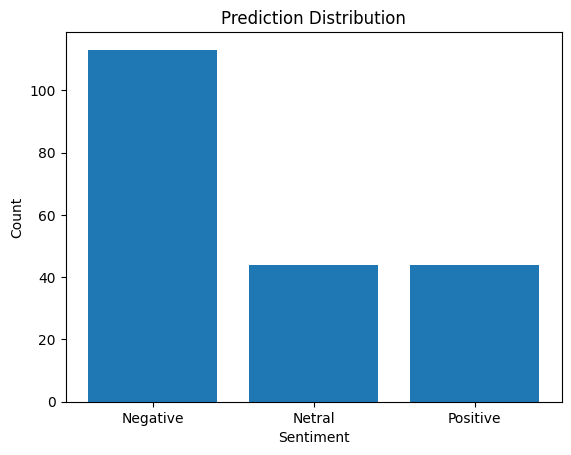

In [52]:
counts = {0: 0, 1: 0, 2: 0}

for p in preds:
    counts[p] += 1

neg = counts[0]
net = counts[1]
pos = counts[2]

import matplotlib.pyplot as plt

labels = ["Negative", "Netral", "Positive"]
values = [neg, net, pos]

plt.bar(labels, values)

plt.title("Prediction Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

# 8. Evaluate Performance

In [48]:
preds_labeled = [labels[x] for x in preds]
trues_labeled = [labels[x] for x in trues]

print(preds_labeled)
print(trues_labeled)

['Netral', 'Negative', 'Netral', 'Negative', 'Positive', 'Negative', 'Negative', 'Positive', 'Netral', 'Positive', 'Negative', 'Negative', 'Negative', 'Positive', 'Negative', 'Netral', 'Negative', 'Positive', 'Netral', 'Negative', 'Negative', 'Negative', 'Positive', 'Netral', 'Positive', 'Negative', 'Negative', 'Netral', 'Positive', 'Positive', 'Negative', 'Negative', 'Negative', 'Negative', 'Negative', 'Positive', 'Negative', 'Negative', 'Negative', 'Negative', 'Positive', 'Positive', 'Negative', 'Netral', 'Negative', 'Negative', 'Negative', 'Positive', 'Netral', 'Negative', 'Netral', 'Netral', 'Negative', 'Positive', 'Negative', 'Negative', 'Negative', 'Netral', 'Netral', 'Negative', 'Negative', 'Negative', 'Negative', 'Netral', 'Negative', 'Negative', 'Positive', 'Positive', 'Negative', 'Positive', 'Negative', 'Positive', 'Negative', 'Positive', 'Positive', 'Netral', 'Negative', 'Negative', 'Negative', 'Positive', 'Netral', 'Netral', 'Positive', 'Negative', 'Negative', 'Negative', '

## 8.1 Confusion Matrix

In [49]:
cm = confusion_matrix(true_labels, preds)

cm_df = pd.DataFrame(cm, index=labels, columns=labels)

print(cm_df)

          Negative  Positive  Netral
Negative        88        14       7
Positive        18        20      15
Netral           7        10      22


## 8.2 Accuracy

In [50]:
correct = 0

for i in range(len(preds)):
    if preds[i] == true_labels[i]:
        correct += 1

accuracy = correct / len(preds)

print("Accuracy:", accuracy)

Accuracy: 0.6467661691542289


## 8.3 Precision, Recall

In [58]:
results = {}

for cls in labels:
    tp = 0
    fp = 0
    fn = 0

    for i in range(len(trues_labeled)):
        if preds_labeled[i] == cls and trues_labeled[i] == cls:
            tp += 1
        elif preds_labeled[i] == cls and trues_labeled[i] != cls:
            fp += 1
        elif preds_labeled[i] != cls and trues_labeled[i] == cls:
            fn += 1

    # avoid division by zero
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    results[cls] = {
        "precision": precision,
        "recall": recall
    }

for k in results.keys():
    print(k, ":", results[k])

Negative : {'precision': 0.7787610619469026, 'recall': 0.8073394495412844}
Netral : {'precision': 0.5, 'recall': 0.5641025641025641}
Positive : {'precision': 0.45454545454545453, 'recall': 0.37735849056603776}
